# **Predict The Price**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

1) Collect and Preprocess Dataset

In [2]:
df = pd.read_csv('laptop_price - dataset.csv')
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (1275, 15)


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00


In [3]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
CPU_Company,0
CPU_Type,0
CPU_Frequency (GHz),0
RAM (GB),0
Memory,0


In [4]:
X = df.drop(columns=['Price (Euro)', 'Product'])
y = df['Price (Euro)']
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numerical_cols = [c for c in X.columns if X[c].dtype in ["int64", "float64"]]

print(f"Features selected for model: {list(X.columns)}")
print(f"Target variable: Price (Euro)")

Features selected for model: ['Company', 'TypeName', 'Inches', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)']
Target variable: Price (Euro)


In [5]:
numerical_transformer = SimpleImputer(strategy='mean')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into Train (80%) and Test (20%) sets.")

Data split into Train (80%) and Test (20%) sets.


2) Explore and Analyze

In [6]:
average_price = df['Price (Euro)'].mean()
print(f"The average price of laptops in the dataset is: €{average_price:,.2f}")

The average price of laptops in the dataset is: €1,134.97


<Axes: xlabel='Price (Euro)', ylabel='Count'>

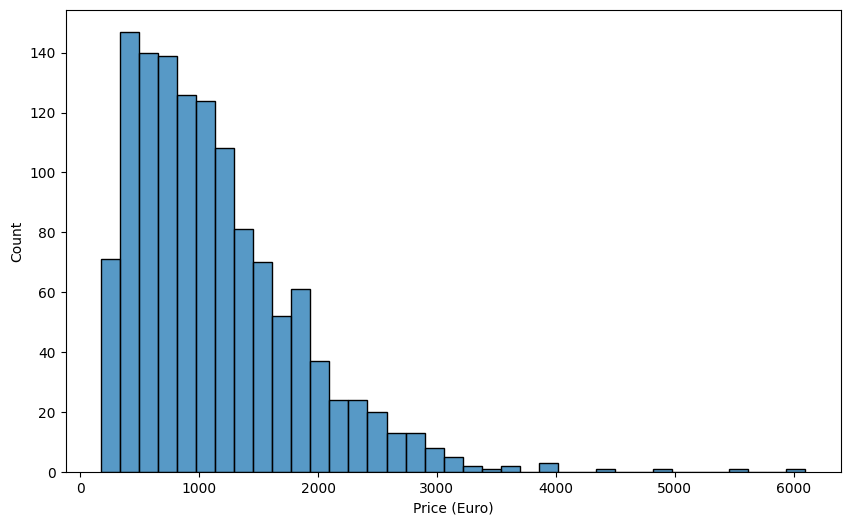

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price (Euro)'])


Correlation of Numerical Features with Price:
Price (Euro)           1.000000
RAM (GB)               0.740287
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


/tmp/ipykernel_202/1082875831.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.drop('Price (Euro)').index, y=correlations.drop('Price (Euro)').values, palette='viridis')


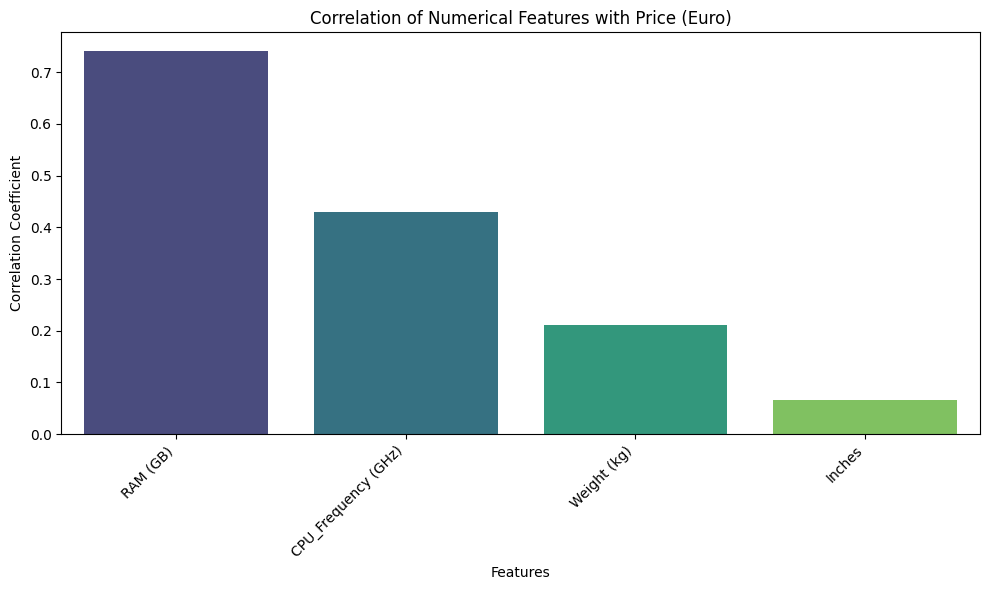

In [8]:
# Extracting correlation of numerical features with the target variable
print("\nCorrelation of Numerical Features with Price:")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Price (Euro)'].sort_values(ascending=False)
print(correlations)

# Plotting the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.drop('Price (Euro)').index, y=correlations.drop('Price (Euro)').values, palette='viridis')
plt.title('Correlation of Numerical Features with Price (Euro)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
print("Statistical Summary of Numerical Features:")
print(df.describe().to_string())

Statistical Summary of Numerical Features:
            Inches  CPU_Frequency (GHz)     RAM (GB)  Weight (kg)  Price (Euro)
count  1275.000000          1275.000000  1275.000000  1275.000000   1275.000000
mean     15.022902             2.302980     8.440784     2.040525   1134.969059
std       1.429470             0.503846     5.097809     0.669196    700.752504
min      10.100000             0.900000     2.000000     0.690000    174.000000
25%      14.000000             2.000000     4.000000     1.500000    609.000000
50%      15.600000             2.500000     8.000000     2.040000    989.000000
75%      15.600000             2.700000     8.000000     2.310000   1496.500000
max      18.400000             3.600000    64.000000     4.700000   6099.000000


In [10]:
print("\nCorrelation of Numerical Features with Price:")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Price (Euro)'].sort_values(ascending=False)
print(correlations)


Correlation of Numerical Features with Price:
Price (Euro)           1.000000
RAM (GB)               0.740287
CPU_Frequency (GHz)    0.428847
Weight (kg)            0.211883
Inches                 0.066608
Name: Price (Euro), dtype: float64


3) Apply Supervised Learning Algorithms

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

trained_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    print(f"Model '{name}' has been trained.")

Model 'Linear Regression' has been trained.
Model 'Random Forest' has been trained.
Model 'Decision Tree' has been trained.


4) Evaluate and Compare Performance

In [12]:
best_model = None
best_score = -float('inf')
best_model_name = ""

for name, clf in trained_models.items():
    y_pred = clf.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Results for {name}:")
    print(f"  MAE (Mean Absolute Error):  {mae:.2f} Euro")
    print(f"  RMSE (Root Mean Sq Error):  {rmse:.2f} Euro")
    print(f"  R² Score (Accuracy):        {r2:.4f}")

    if r2 > best_score:
        best_score = r2
        best_model = clf
        best_model_name = name

print("-" * 30)
print(f"The best performing model is: {best_model_name} with R² = {best_score:.4f}")

Results for Linear Regression:
  MAE (Mean Absolute Error):  216.15 Euro
  RMSE (Root Mean Sq Error):  302.07 Euro
  R² Score (Accuracy):        0.8162
Results for Random Forest:
  MAE (Mean Absolute Error):  176.52 Euro
  RMSE (Root Mean Sq Error):  262.16 Euro
  R² Score (Accuracy):        0.8615
Results for Decision Tree:
  MAE (Mean Absolute Error):  234.40 Euro
  RMSE (Root Mean Sq Error):  332.44 Euro
  R² Score (Accuracy):        0.7773
------------------------------
The best performing model is: Random Forest with R² = 0.8615


5) Simple Price Prediction System

In [13]:
print("PREDICTION RESULT: 10 Random Samples")

sample_indices = X_test.sample(10, random_state=1).index
sample_X = X.loc[sample_indices]
sample_y_true = y.loc[sample_indices]


sample_y_pred = clf.predict(sample_X)

print(f"{'Brand':<12} | {'RAM':<5} | {'CPU':<15} | {'Actual (€)':<12} | {'Predicted (€)':<12} | {'Diff (€)':<10}")
print("-" * 90)

for i in range(len(sample_indices)):
    brand = sample_X.iloc[i]['Company']
    ram = sample_X.iloc[i]['RAM (GB)']
    cpu = sample_X.iloc[i]['CPU_Type']
    actual = sample_y_true.iloc[i]
    predicted = sample_y_pred[i]
    diff = abs(actual - predicted)

    print(f"{brand:<12} | {ram:<5} | {cpu:<15} | {actual:<12.2f} | {predicted:<12.2f} | {diff:<10.2f}")

PREDICTION RESULT: 10 Random Samples
Brand        | RAM   | CPU             | Actual (€)   | Predicted (€) | Diff (€)  
------------------------------------------------------------------------------------------
Dell         | 16    | Core i7 8550U   | 1285.00      | 1159.00      | 126.00    
Dell         | 12    | Core i7 7500U   | 713.07       | 638.99       | 74.08     
Dell         | 4     | Core i3 6006U   | 614.00       | 558.60       | 55.40     
Dell         | 8     | Core i5 7200U   | 795.00       | 750.00       | 45.00     
Dell         | 32    | Core i7 7700HQ  | 3588.80      | 3147.37      | 441.43    
Lenovo       | 8     | Core i5 7200U   | 1345.00      | 1010.51      | 334.49    
Mediacom     | 4     | Celeron Dual Core N3350 | 299.00       | 603.00       | 304.00    
Dell         | 8     | Core i5 6200U   | 649.00       | 1229.00      | 580.00    
Dell         | 8     | Core i7 8550U   | 1049.00      | 884.00       | 165.00    
Google       | 8     | Core i5 7Y57    | 15

Scope Check: Currency is set to EURO.
Scope Check: Using CPU, RAM, Storage, Brand, Screen Size.

Simulated User Input (Laptop Specs):
  Company: HP
  TypeName: Notebook
  Inches: 15.6
  ScreenResolution: 1366x768
  CPU_Company: Intel
  CPU_Type: Core i3 6100U
  CPU_Frequency (GHz): 2.3
  RAM (GB): 4
  Memory: 500GB HDD
  GPU_Company: Intel
  GPU_Type: HD Graphics 520
  OpSys: Windows 10
  Weight (kg): 2.07
--------------------------------------------------
PREDICTED PRICE: €765.69
ACTUAL PRICE:    €650.00
DIFFERENCE:      €115.69
--------------------------------------------------


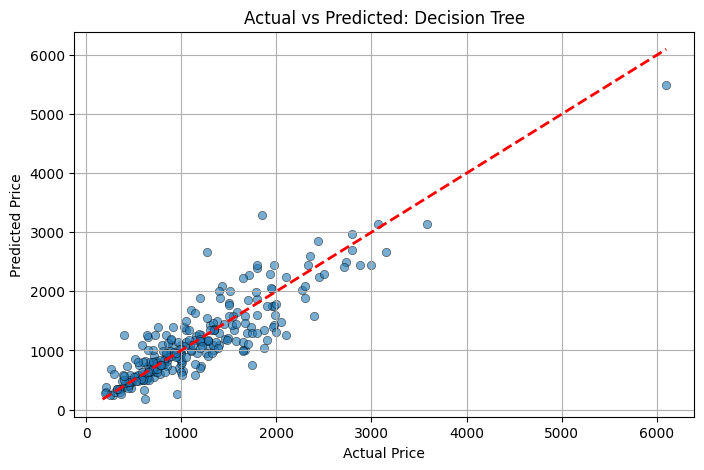

In [14]:
print("Scope Check: Currency is set to EURO.")
print("Scope Check: Using CPU, RAM, Storage, Brand, Screen Size.")
sample_idx = 0
user_input_simulation = X_test.iloc[[sample_idx]]
actual_value = y_test.iloc[sample_idx]

print("\nSimulated User Input (Laptop Specs):")
# Display the input details nicely
for col in X.columns:
    val = user_input_simulation[col].values[0]
    print(f"  {col}: {val}")

# Predict using the best model found in Objective 4
predicted_price = best_model.predict(user_input_simulation)[0]

print("-" * 50)
print(f"PREDICTED PRICE: \u20ac{predicted_price:,.2f}")
print(f"ACTUAL PRICE:    \u20ac{actual_value:,.2f}")
print(f"DIFFERENCE:      \u20ac{abs(predicted_price - actual_value):,.2f}")
print("-" * 50)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, edgecolor='k')
# Draw the "Perfect Prediction" line (y = x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted: {name}')
plt.grid(True)
plt.show()

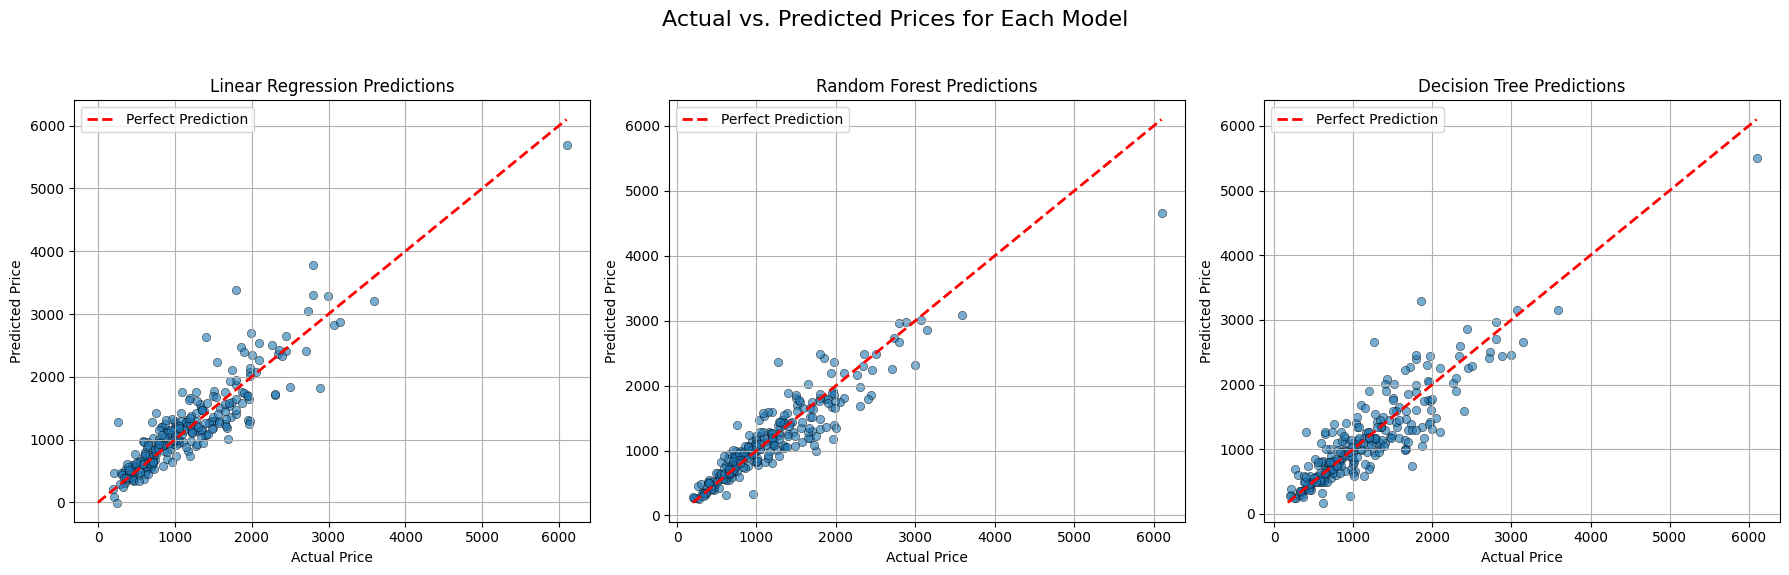

In [15]:
# Determine the number of models to plot
num_models = len(trained_models)

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 6))

# If there's only one model, axes might not be an array, so convert it
if num_models == 1:
    axes = [axes]

fig.suptitle('Actual vs. Predicted Prices for Each Model', fontsize=16)

for i, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)

    ax = axes[i]
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, edgecolor='k', ax=ax)

    # Determine the min and max values for the diagonal line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name} Predictions')
    ax.grid(True)
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()